In [2]:
# ============================================
# 0) Imports
# ============================================
import albumentations as A
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns



print(tf.__version__)
print("All imports work correctly ✅")
print(A.__version__)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2.18.0
All imports work correctly ✅
2.0.8


In [3]:



# ============================================
# 1) Preprocessing Function
# ============================================
def preprocess_image(img, target_size=(224, 224)):
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    img = cv2.resize(img, target_size)

    kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
    img = cv2.filter2D(img, -1, kernel)

    img = img / 255.0
    return img


# ============================================
# 2) Albumentations Augmentation Pipeline
# ============================================
def get_augmentation_pipeline(target_size=(299, 299)):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT, p=0.5),
        A.RandomResizedCrop(size=target_size, scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.1,
            rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT,
            p=0.5
        ),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5)
    ])
    return transform



# ============================================
# 3) Load Images from Folder (Ignore Mask folders)
# ============================================
def get_images_from_folder(base_path):
    images_list = []
    for root, dirs, files in os.walk(base_path):
        if 'Mask' in root.split(os.sep):
            continue
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images_list.append(os.path.join(root, file))
    return images_list


# ============================================
# 4) Custom Data Generator
# ============================================

class ImageDataGeneratorSequence(Sequence):
    def __init__(self, food_paths, fruit_paths, batch_size=32, augment=False,
                 target_size=(299, 299), shuffle=True, target_count_per_class=None):
        self.food_paths  = food_paths
        self.fruit_paths = fruit_paths
        self.batch_size  = batch_size
        self.augment     = augment
        self.target_size = target_size
        self.shuffle     = shuffle
        self.target_count_per_class = target_count_per_class
        self.transform = get_augmentation_pipeline(self.target_size) if self.augment else None


        if self.augment and self.target_count_per_class:
            self.food_paths = self._oversample(self.food_paths, self.target_count_per_class)
            self.fruit_paths = self._oversample(self.fruit_paths, self.target_count_per_class)

        self.all_paths = self.food_paths + self.fruit_paths
        self.labels = np.array([0]*len(self.food_paths) + [1]*len(self.fruit_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.all_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.all_paths[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_images = []
        batch_labels_clean = []

        for path, label in zip(batch_paths, batch_labels):
            img = cv2.imread(path)
            if img is None:
                print(f"⚠️ Warning: Could not load image {path}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if self.augment:

                img = self.transform(image=img)["image"]

            img = preprocess_image(img, self.target_size)
            batch_images.append(img)
            batch_labels_clean.append(label)

        return np.array(batch_images), np.array(batch_labels_clean)

    def on_epoch_end(self):
        if self.shuffle:
            idxs = np.arange(len(self.all_paths))
            np.random.shuffle(idxs)
            self.all_paths = [self.all_paths[i] for i in idxs]
            self.labels = self.labels[idxs]

    # =================================
    # Utility functions
    # =================================
    def _oversample(self, paths, target_count):
        if len(paths) >= target_count:
            return paths[:target_count]
        extra = []
        while len(paths) + len(extra) < target_count:
            extra += paths
        return paths + extra[:target_count - len(paths)]

# ============================================
# 5) PATHS
# ============================================
food_train_path = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Food/Train"
food_test_path  = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Food/Validation"
fruit_train_path = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Fruit/Train"
fruit_test_path  = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Fruit/Validation"


# ============================================
# 6) Load Images + Split
# ============================================
food_train_images_all = get_images_from_folder(food_train_path)
food_test_images = get_images_from_folder(food_test_path)
fruit_train_images_all = get_images_from_folder(fruit_train_path)
fruit_test_images = get_images_from_folder(fruit_test_path)

food_train_images, food_val_images = train_test_split(food_train_images_all, test_size=0.2, random_state=42)
fruit_train_images, fruit_val_images = train_test_split(fruit_train_images_all, test_size=0.2, random_state=42)


# ============================================
# 7) Generators
# ============================================
batch_size = 32

train_gen = ImageDataGeneratorSequence(food_train_images, fruit_train_images, batch_size=batch_size, augment=True,target_count_per_class=2100)
val_gen   = ImageDataGeneratorSequence(food_val_images, fruit_val_images, batch_size=batch_size, augment=False)
test_gen  = ImageDataGeneratorSequence(food_test_images, fruit_test_images, batch_size=batch_size, augment=False, shuffle=False)

print("📊 Number of training paths per class:")
print(f"Food paths: {len(train_gen.food_paths)}")
print(f"Fruit paths: {len(train_gen.fruit_paths)}")
print(f"Total paths in generator: {len(train_gen.all_paths)}")

print("data managed")

📊 Number of training paths per class:
Food paths: 2100
Fruit paths: 2100
Total paths in generator: 4200
data managed


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


I0000 00:00:1765459067.753707      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765459067.754336      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
▶️ Training Head (Frozen InceptionResNetV2)...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1765459091.722061     119 service.cc:148] XLA service 0x7bd5c00d5f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765459091.722956     119 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765459091.722976     119 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765459096.291515     119 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1765459108.857844     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 148s 867ms/step - accuracy: 0.5220 - loss: 0.7357 - val_accuracy: 0.9616 - val_loss: 0.4220 - learning_rate: 1.0000e-04
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 61s 458ms/step - accuracy: 0.9050 - loss: 0.4005 - val_accuracy: 0.9907 - val_loss: 0.2551 - learning_rate: 1.0000e-04
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 59s 448ms/step - accuracy: 0.9668 - loss: 0.2582 - val_accuracy: 0.9907 - val_loss: 0.1739 - learning_rate: 1.0000e-04
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 59s 447ms/step - accuracy: 0.9773 - loss: 0.1906 - val_accuracy: 0.9930 - val_loss: 0.1323 - learning_rate: 1.0000e-04
Epoch 5/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 60s 454ms/step - accuracy: 0.9851 - loss: 0.1498 - val_accuracy: 0.9942 - val_loss: 0.1038 - learning_rate: 1.0000e-04
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step 
✔️ Final Test Accuracy: 99.76%

📌 Classification Report:
              precision    recall  f1-score   support

        Food       1.00      1.00      1.00       261
       Fruit 

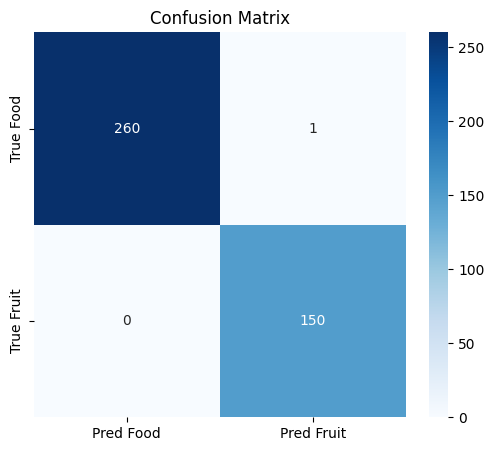

✔️ Final model saved successfully!
✔️ Final model saved successfully!


In [4]:
# ============================================
# 8) Build Model with InceptionResNetV2
# ============================================
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    min_delta=0.001,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    mode='max',
    min_lr=1e-7,
    verbose=1
)

# Base model
base_model = InceptionResNetV2(
    input_shape=(299, 299, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# Head
inputs = tf.keras.Input(shape=(299, 299, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  # Slightly higher dropout for larger model
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ============================================
# 9) Train Head (Frozen backbone)
# ============================================
print("▶️ Training Head (Frozen InceptionResNetV2)...")
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
# ============================================
# 11) Evaluate on Test Set
# ============================================
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.labels[:len(y_pred)]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
acc = accuracy_score(y_true, y_pred)
print(f"✔️ Final Test Accuracy: {acc*100:.2f}%")

print("\n📌 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Food", "Fruit"]))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Food", "Pred Fruit"],
    yticklabels=["True Food", "True Fruit"]
)
plt.title("Confusion Matrix")
plt.show()

# ============================================
# 12) Save Final Model
# ============================================
model.save(f"final_model_inceptionresnet_acc_{acc:.4f}.h5")
print("✔️ Final model saved successfully!")

model.save(f"Model_inceptionresnetv2_acc_{acc:.2f}..keras")
print("✔️ Final model saved successfully!")

▶️ Fine-tuning last 50 layers...
Epoch 1/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 120s 657ms/step - accuracy: 0.9290 - loss: 0.2675 - val_accuracy: 0.9930 - val_loss: 0.1142 - learning_rate: 1.0000e-06
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 62s 468ms/step - accuracy: 0.9654 - loss: 0.1965 - val_accuracy: 0.9953 - val_loss: 0.1021 - learning_rate: 1.0000e-06
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 62s 468ms/step - accuracy: 0.9707 - loss: 0.1553 - val_accuracy: 0.9953 - val_loss: 0.0856 - learning_rate: 1.0000e-06
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 60s 450ms/step - accuracy: 0.9881 - loss: 0.1164 - val_accuracy: 0.9965 - val_loss: 0.0719 - learning_rate: 1.0000e-06
Epoch 5/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 61s 458ms/step - accuracy: 0.9858 - loss: 0.1030 - val_accuracy: 0.9965 - val_loss: 0.0609 - learning_rate: 1.0000e-06
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step 
✔️ Final Test Accuracy: 100.00%

📌 Classification Report:
              precision    recall  f1-score   support

        Food       1.00

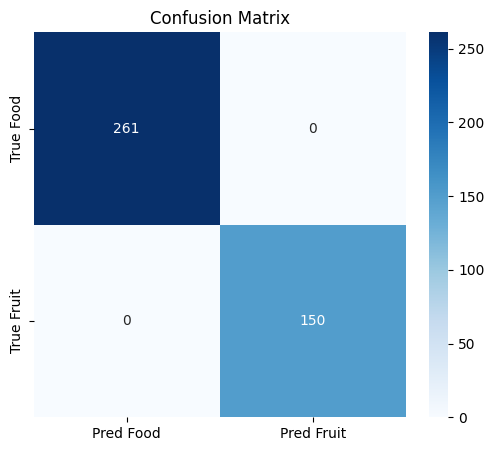

✔️ Final model saved successfully!
✔️ Final model saved successfully!


In [5]:

# ============================================
# 10) Fine-tune last layers
# ============================================
base_model.trainable = True
# Freeze all but last 100 layers (InceptionResNetV2 has ~500+ layers)
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("▶️ Fine-tuning last 50 layers...")
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ============================================
# 11) Evaluate on Test Set
# ============================================
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.labels[:len(y_pred)]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
acc = accuracy_score(y_true, y_pred)
print(f"✔️ Final Test Accuracy: {acc*100:.2f}%")

print("\n📌 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Food", "Fruit"]))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Food", "Pred Fruit"],
    yticklabels=["True Food", "True Fruit"]
)
plt.title("Confusion Matrix")
plt.show()

# ============================================
# 12) Save Final Model
# ============================================
model.save(f"final_model_inceptionresnet2_acc_{acc:.4f}.h5")
print("✔️ Final model saved successfully!")
model.save(f"Final_model_inceptionresnetv2_acc_{acc:.2f}..keras")
print("✔️ Final model saved successfully!")